# Overview: Malignant subtype analysis using baseline methods on the HGSOC dataset

This notebook analyzes malignant-cell heterogeneity in the HGSOC dataset using two baseline approaches, **Scanpy** and **Banksy**, and compares their subtype-identification results in a consistent framework.

The workflow includes:

1. **Load the processed HGSOC data**
   Load the SpiderNet run directory and the processed AnnData objects, then select **malignant cells** for downstream analysis.

2. **Generate a transcriptomics-based baseline with Scanpy**
   Apply a standard single-cell workflow to malignant cells, including log-normalization, highly variable gene selection, PCA, neighborhood graph construction, Louvain clustering, and UMAP embedding.

3. **Import and organize Banksy results**
   Load the precomputed Banksy UMAP coordinates and cluster assignments, align them to the same malignant cells, and store them in an AnnData object for direct comparison.

4. **Visualize subtype patterns**
   Plot UMAPs colored by tissue annotations and cluster labels to examine how malignant-cell subtypes are organized under each baseline method.

5. **Assess embedding quality across samples**
   Compute silhouette scores on subsampled cells to evaluate how strongly the low-dimensional embeddings are separated by sample identity.

Overall, this notebook provides a baseline analysis of malignant-cell subtype structure in HGSOC and creates a reference for comparison with MI-based subtype analyses.

## 1. Imports and device setup

In [1]:
import json
from SpiderNet.utils import *
from SpiderNet.config import *
from dataclasses import fields
import scanpy as sc
import gseapy as gp

cuda_available = torch.cuda.is_available()
if cuda_available:
    device = "cuda"
else:
    device = "cpu"
print(f"Using device: {device}")

C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Using device: cuda


## 2. Configure paths

In [2]:
from pathlib import Path

PROCESSED_DATA_DIR = Path("D:/SpiderNet/Results/HGSOC/ProcessedData")
OUTPUT_ROOT = Path("D:/SpiderNet/Results/HGSOC")
DATA_ROOT = Path("D:/SpiderNet/Data/HGSOC")

setup_path = OUTPUT_ROOT / "HGSOC_modeltraining_setup.json"
if setup_path.exists():
    with open(setup_path, "r", encoding="utf-8") as handle:
        training_setup = json.load(handle)
    PROCESSED_DATA_DIR = Path(training_setup.get("PROCESSED_DATA_DIR", PROCESSED_DATA_DIR))
    OUTPUT_ROOT = Path(training_setup.get("OUTPUT_ROOT", OUTPUT_ROOT))

print(f"Processed data: {PROCESSED_DATA_DIR}")
print(f"Training results: {OUTPUT_ROOT}")
print(f"Auxiliary data: {DATA_ROOT}")

Processed data: D:\SpiderNet\Results\HGSOC\ProcessedData
Training results: D:\SpiderNet\Results\HGSOC
Auxiliary data: D:\SpiderNet\Data\HGSOC


## 3. Load training results

In [3]:
import re

run_dirs_path = OUTPUT_ROOT / "run_dirs.json"
if not run_dirs_path.exists():
    raise FileNotFoundError(f"Cannot find run_dirs.json: {run_dirs_path}")

with open(run_dirs_path, "r", encoding="utf-8") as handle:
    run_dirs = json.load(handle)

run_dir = Path(run_dirs["run_dir"])
match = re.search(r"Result_dim(\d+)", str(run_dir))
if match is None:
    raise ValueError(f"Cannot parse dim_envir from run directory: {run_dir}")
dim_envir = int(match.group(1))

print(run_dirs)
print(f"dim_envir = {dim_envir}")

{'run_dir': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15', 'model_dir': 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\Model'}
dim_envir = 15


## 4. Load processed HGSOC data

In [4]:
from SpiderNet.io import load_processed_data
processed = load_processed_data(PROCESSED_DATA_DIR)

[f.name for f in fields(processed)]

['adata_all',
 'spidernet_data',
 'metadata_sample',
 'lr_list',
 'batch_cell_unique',
 'genenames_train',
 'lr_list_cellchatdb',
 'lr_meta_cellchatdb',
 'batch_cell',
 'adata_list']

In [5]:
processed.spidernet_data = [data.to(device) for data in processed.spidernet_data]

## 5. Show the cell subtype identification results of baseline methods

### Specify the cell class to analyze

In [6]:
cellclass_choose = 'Malignant'

In [7]:
adata_choose_path = run_dirs['run_dir'] + "/" + ("adata_choose_" + str(cellclass_choose) + ".h5ad")
adata_choose = sc.read_h5ad(adata_choose_path)
print(adata_choose)

AnnData object with n_obs × n_vars = 203476 × 979
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'samples', 'patients_x', 'sites_binary_x', 'cell.types', 'cell.subtypes', 'x', 'y', 'SAMPLE_ID', 'CELL_TYPE', 'dataset', 'platform_x', 'n_cells_x', 'median_tpc_x', 'mean_tpc_x', 'TMA_x', 'age_x', 'stage_x', 'treatment_x', '1L_x', 'parpi_x', 'immunotherapy_x', 'fu_time1_x', 'fu_time2_x', 'outcome_x', 'pfs_x', 'BRCA1_Somatic_x', 'BRCA2_Somatic_x', 'TP53_Somatic_x', 'BRCA1_Germline_x', 'BRCA2_Germline_x', 'TP53_Germline_x', 'tmb_x', '_concat_batch', 'B.cell_prop', 'Endothelial_prop', 'Fibroblast_prop', 'Malignant_prop', 'Mast.cell_prop', 'Monocyte_prop', 'TNK.cell_prop', 'barcode', 'platform_y', 'n_cells_y', 'median_tpc_y', 'mean_tpc_y', 'TMA_y', 'patients_y', 'sites_binary_y', 'age_y', 'stage_y', 'treatment_y', '1L_y', 'parpi_y', 'immunotherapy_y', 'fu_time1_y', 'fu_time2_y', 'outcome_y', 'pfs_y', 'BRCA1_Somatic_y', 'BRCA2_Somatic_y', 'TP53_Somatic_y', 'BRCA1_Germline_y', 'BRCA2_Germlin

### Scanpy

In [8]:
import scanpy as sc

def run_logPCAUMAP(
    adata_choose,
    n_hvg=2000,
    n_pcs=50,
    n_neighbors=15,
    umap_min_dist=0.5,
    umap_spread=1.0,
    use_raw_counts=True,
    random_state=0
):
    """
    log normalized -> HVG -> scale -> PCA -> neighbors -> UMAP
    Results:
      adata_choose.X: log1p normalized (or stays same if you disable)
      adata_choose.obsm["X_pca"]
      adata_choose.obsm["X_umap"]
    """

    adata = adata_choose.copy()

    # ---------- 0) ensure counts ----------
    # If you want to start from raw counts (recommended):
    if use_raw_counts:
        # common patterns: adata.layers["counts"] exists OR adata.raw exists
        if hasattr(adata, "layers") and ("counts" in adata.layers.keys()):
            adata.X = adata.layers["counts"].copy()
        elif adata.raw is not None:
            adata.X = adata.raw.X.copy()
        # else: assume adata.X is already counts

    # ---------- 1) normalization + log ----------
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # ---------- 2) HVG ----------
    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=n_hvg,
        flavor="seurat_v3"  # robust default
    )
    adata = adata[:, adata.var["highly_variable"]].copy()

    # ---------- 3) scale ----------
    sc.pp.scale(adata, max_value=10)

    # ---------- 4) PCA ----------
    sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack", random_state=random_state)

    # ---------- 5) neighbors ----------
    sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=min(n_pcs, adata.obsm["X_pca"].shape[1]))
    
    # optional: clustering (e.g., Louvain) before UMAP
    sc.tl.louvain(adata, resolution=0.17, key_added='X_louvain')

    # ---------- 6) UMAP ----------
    sc.tl.umap(adata, min_dist=umap_min_dist, spread=umap_spread, random_state=random_state)

    return adata

adata_choose2 = run_logPCAUMAP(adata_choose)
adata_choose2.write_h5ad(run_dirs['run_dir'] + f"/adata_choose2_{cellclass_choose}.h5ad")

C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\legacy_api_wrap\__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [9]:
run_dirs['run_dir']

'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15'

In [10]:
##load adata_choose2
adata_choose2 = sc.read_h5ad(run_dirs['run_dir'] + f"/adata_choose2_{cellclass_choose}.h5ad")

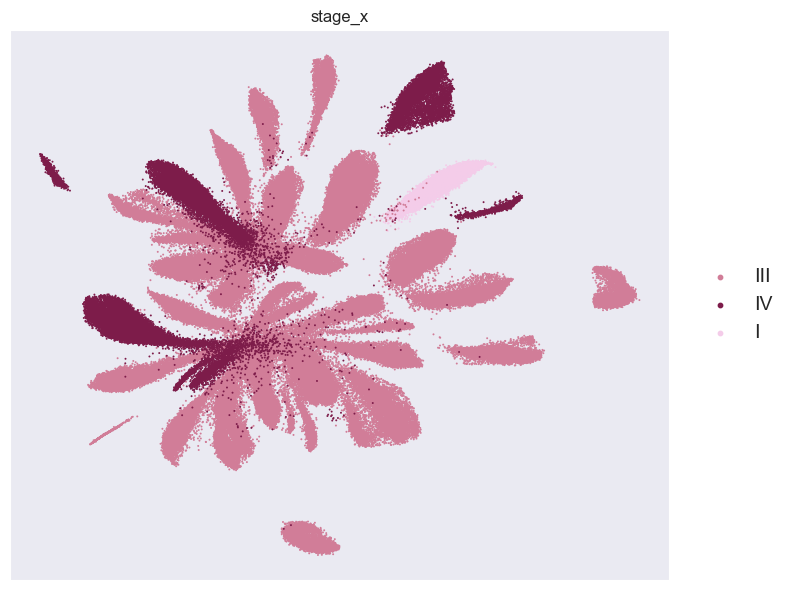

In [11]:
from SpiderNet.analysis import Feature_show_umap
Feature_show_umap(
    cellclass_choose=cellclass_choose,
    adata_choose_path=run_dirs['run_dir'] + f"/adata_choose2_{cellclass_choose}.h5ad",
    file_savepath_main=run_dirs['run_dir'],
    obsm_show="X_umap",
    adata_copy_path=str(PROCESSED_DATA_DIR / "adata_all.h5ad"),
    show=True
)

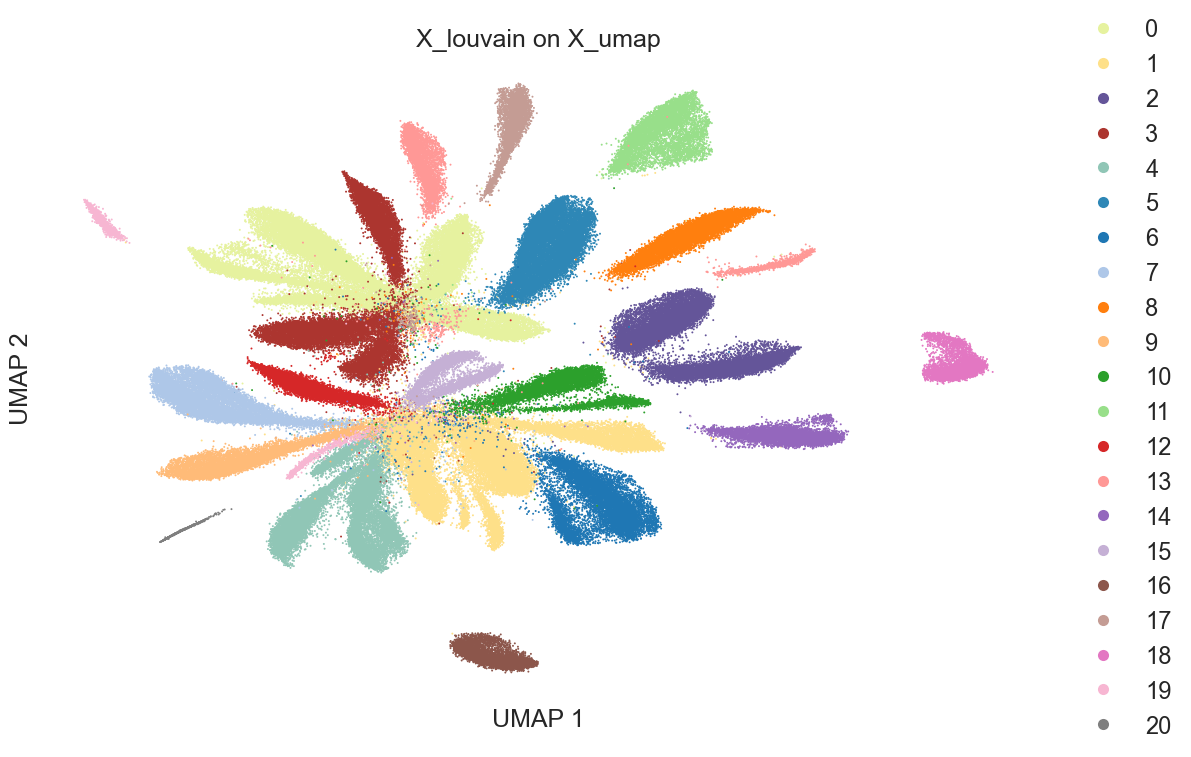

('D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\UMAP_Malignant_Xlouvain.png',
 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\UMAP_Malignant_Xlouvain.pdf')

In [12]:
from SpiderNet.analysis import plot_louvain_umap
plot_louvain_umap(
    adata_choose2,
    obsm_key="X_umap",       
    louvain_key="X_louvain", 
    out_dir=run_dirs['run_dir'],
    out_prefix=f"UMAP_{cellclass_choose}_Xlouvain",
    title=None,
    size=2,
    show=True
)


In [13]:
##Calculate silhouette score
import numpy as np
from sklearn.metrics import silhouette_samples

# embedding and labels
X = adata_choose2.obsm['X_umap']
labels = adata_choose2.obs['samples'].values

# subsample
np.random.seed(0)
n_cells = X.shape[0]
n_sub = max(int(n_cells * 0.30), 1000)
idx = np.random.choice(n_cells, size=n_sub, replace=False)

X_sub = X[idx]
labels_sub = labels[idx]
print(f"Computing silhouette score on {n_sub} subsampled cells (out of {n_cells})...")

# compute silhouette on subsampled cells
sil_scores_sub = silhouette_samples(X_sub, labels_sub, metric='euclidean')
asw_sub = sil_scores_sub.mean()

print("Subsampled mean silhouette score:", asw_sub)

Computing silhouette score on 61042 subsampled cells (out of 203476)...
Subsampled mean silhouette score: 0.31402624


### Banksy

In [14]:
banksy_umap_path = DATA_ROOT / "Banksy/" f"Banksy_Umap_{cellclass_choose}.csv"
banksy_cluster_df_path = DATA_ROOT / "Banksy/" f"Banksy_cluster_{cellclass_choose}.csv"
banksy_umap_df = pd.read_csv(banksy_umap_path, index_col=0)
banksy_cluster_df = pd.read_csv(banksy_cluster_df_path, index_col=0)
adata_choose3 = adata_choose.copy()
#########################
cells = adata_choose3.obs['barcode'].tolist()

umap_cols = banksy_umap_df.columns[:2]
banksy_umap_df_use = banksy_umap_df.loc[:, umap_cols].copy()
banksy_umap_df_use.index = banksy_umap_df_use.index.astype(str)

cluster_col = banksy_cluster_df.columns[0]
banksy_cluster_s = banksy_cluster_df[cluster_col].copy()
banksy_cluster_s.index = banksy_cluster_s.index.astype(str)
#########################
umap_aligned = banksy_umap_df_use.reindex(cells)
cluster_aligned = banksy_cluster_s.reindex(cells)

n_missing_umap = umap_aligned.isna().any(axis=1).sum()
n_missing_cluster = cluster_aligned.isna().sum()
print(f"Missing UMAP rows after align: {n_missing_umap}/{len(cells)}")
print(f"Missing cluster after align: {n_missing_cluster}/{len(cells)}")
#########################
# -----------------------------
adata_choose3.obsm["Banksy_umap"] = umap_aligned.values.astype(float)
adata_choose3.obs["Banksy_louvain"] = np.array(cluster_aligned.astype("category"))
adata_choose3.obs["Banksy_louvain"] = adata_choose3.obs["Banksy_louvain"].astype("category")
##Save adata_choose3
adata_choose3.write_h5ad(run_dirs['run_dir'] + f"/adata_choose3_{cellclass_choose}.h5ad")

Missing UMAP rows after align: 0/203476
Missing cluster after align: 0/203476


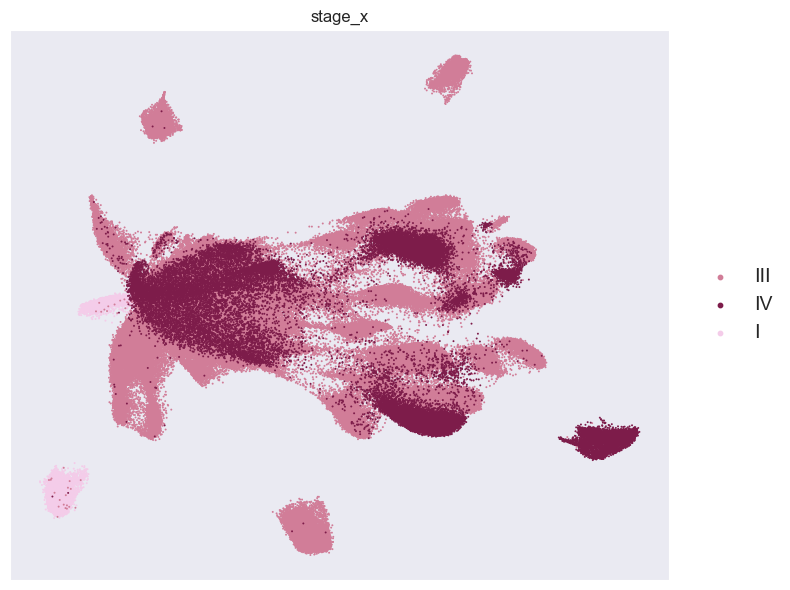

In [15]:
from SpiderNet.analysis import Feature_show_umap
Feature_show_umap(
    cellclass_choose=cellclass_choose,
    adata_choose_path=run_dirs['run_dir'] + f"/adata_choose3_{cellclass_choose}.h5ad",
    file_savepath_main=run_dirs['run_dir'],
    obsm_show="Banksy_umap",
    adata_copy_path=str(PROCESSED_DATA_DIR / "adata_all.h5ad"),
    show=True
)

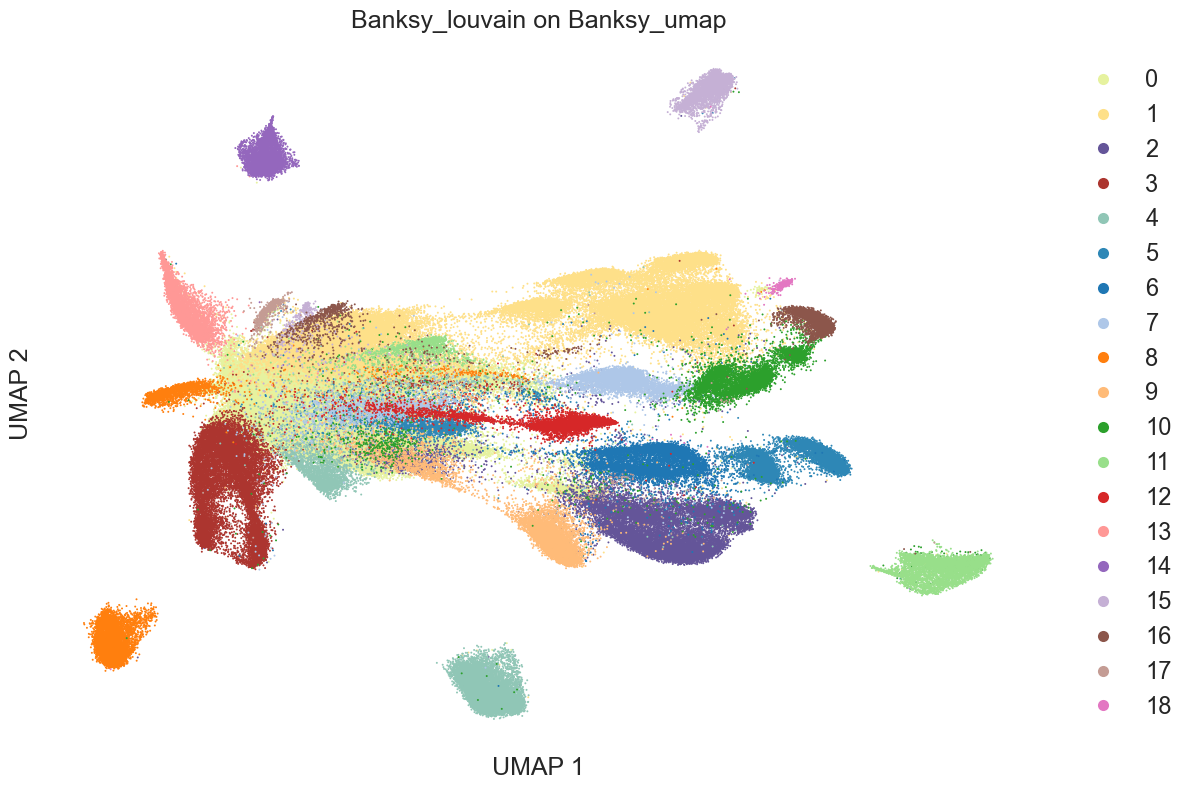

('D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\UMAP_Malignant_BanksyCluster.png',
 'D:\\SpiderNet\\Results\\HGSOC\\V1\\SpiderNet_Result_dim15\\UMAP_Malignant_BanksyCluster.pdf')

In [16]:
from SpiderNet.analysis import plot_louvain_umap
plot_louvain_umap(
    adata_choose3,
    obsm_key="Banksy_umap",       
    louvain_key="Banksy_louvain", 
    out_dir=run_dirs['run_dir'],
    out_prefix=f"UMAP_{cellclass_choose}_BanksyCluster",
    title=None,
    size=2,
    show=True
)


In [17]:
##Calculate silhouette score for Banksy
import numpy as np
from sklearn.metrics import silhouette_samples

# embedding and labels
X = adata_choose3.obsm['Banksy_umap']
labels = adata_choose3.obs['samples'].values

# subsample
np.random.seed(0)
n_cells = X.shape[0]
n_sub = max(int(n_cells * 0.30), 1000)
idx = np.random.choice(n_cells, size=n_sub, replace=False)

X_sub = X[idx]
labels_sub = labels[idx]
print(f"Computing silhouette score on {n_sub} subsampled cells (out of {n_cells})...")

# compute silhouette on subsampled cells
sil_scores_sub = silhouette_samples(X_sub, labels_sub, metric='euclidean')
asw_sub = sil_scores_sub.mean()

print("Subsampled mean silhouette score:", asw_sub)

Computing silhouette score on 61042 subsampled cells (out of 203476)...
Subsampled mean silhouette score: -0.15178395335172518
